In [25]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [26]:
import sys
import os

# Add parent directory to Python path
sys.path.insert(0, os.path.abspath('..'))

# Import FEM modules
from fem.core import Node, Material
from fem.sections import Membrane
from fem.elements import CST, LST, Quad4, Quad9
from fem.utils import get_line_load_global_vector

# Import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import gmsh
import math

In [27]:
# General model parameters
L = 5000 
H = 500  
B = 300
lc = 100
output_path = os.getcwd()
mesh_name = 'calibrated_beam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [28]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)

# Create the corner points of the beam
p1 = gmsh.model.geo.addPoint(0, 0, 0, lc)
p2 = gmsh.model.geo.addPoint(L, 0, 0, lc)
p3 = gmsh.model.geo.addPoint(L, H, 0, lc)
p4 = gmsh.model.geo.addPoint(0, H, 0, lc)

# Punto central inferior
p5 = gmsh.model.geo.addPoint(L/2, 0, 0, lc)

# Punto central superior (donde se aplica la carga)
p6 = gmsh.model.geo.addPoint(L/2, H, 0, lc)

# Define the lines
l1 = gmsh.model.geo.addLine(p1, p5)  # Base izquierda
l2 = gmsh.model.geo.addLine(p5, p2)  # Base derecha
l3 = gmsh.model.geo.addLine(p2, p3)  # Lateral derecho
l4 = gmsh.model.geo.addLine(p3, p6)  # Tope derecho
l5 = gmsh.model.geo.addLine(p6, p4)  # Tope izquierdo
l6 = gmsh.model.geo.addLine(p4, p1)  # Lateral izquierdo
l7 = gmsh.model.geo.addLine(p5, p6)  # Línea vertical central

# Define the surfaces (dos mitades)
# Mitad izquierda
c1 = gmsh.model.geo.addCurveLoop([l1, l7, l5, l6])
s1 = gmsh.model.geo.addPlaneSurface([c1])

# Mitad derecha
c2 = gmsh.model.geo.addCurveLoop([l2, l3, l4, -l7])
s2 = gmsh.model.geo.addPlaneSurface([c2])

# Synchronize the model
gmsh.model.geo.synchronize()
# Create the physical groups
gmsh.model.addPhysicalGroup(2, [s1, s2], 201)  # Superficies de la viga
gmsh.model.setPhysicalName(2, 201, "Beam")

# Apoyos en los nudos extremos inferiores (z=0)
gmsh.model.addPhysicalGroup(0, [p1], 101)  # Nudos en z=0 izquierda y derecha
gmsh.model.setPhysicalName(0, 101, "Support1")

gmsh.model.addPhysicalGroup(0, [p2], 102)  # Nudos en z=0 izquierda y derecha
gmsh.model.setPhysicalName(0, 102, "Support2")

# Carga en el nudo superior central
gmsh.model.addPhysicalGroup(0, [p6], 1)  # Nudo central superior
gmsh.model.setPhysicalName(0, 50, "Load")

# Synchronize the model
gmsh.model.geo.synchronize()



def all_quads():
    # Synchronize geometry before setting meshing options
    gmsh.model.geo.synchronize()
    # Global quad mesh settings
    gmsh.option.setNumber("Mesh.RecombineAll", 1)                # Recombine all triangle meshes into quads
    gmsh.option.setNumber("Mesh.Algorithm", 8)                   # Use Delquad algorithm (for quads)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)      # Use Blossom recombination algorithm
    gmsh.option.setNumber("Mesh.Smoothing", 100)                  # Optional: improve mesh quality
    gmsh.option.setNumber("Mesh.ElementOrder", 1)
all_quads()


In [29]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.000453489s, CPU 0.000772s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay for Quads)
Info    : [  0%] Simple recombination completed (Wall 0.00571952s, CPU 0.005371s): 39 quads, 0 triangles, 0 invalid quads, 0 quads with Q < 0.1, avg Q = 1, min Q = 1
Info    : [  0%] Simple recombination completed (Wall 0.0261039s, CPU 0.024928s): 156 quads, 0 triangles, 0 invalid quads, 0 quads with Q < 0.1, avg Q = 1, min Q = 1
Info    : [ 60%] Meshing surface 2 (Plane, Frontal-Delaunay for Quads)
Info    : [ 60%] Simple recombination completed (Wall 0.00904931s, CPU 0.00821s): 39 quads, 0 triangles, 0 invalid quads, 0 quads with Q 

In [30]:
# Define material
fc_21 = Material(name='fc_21',
                 E=19185.1,
                 nu=0.20,
                 rho=1.25)

# Define membrane section
ConcreteBeam = Membrane(name='ConcreteBeam',
                        thickness=300,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteBeam}

# Define distributed load magnitude
Pload = -98066.5
load_dictionary = {50: Pload}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       102: ['f', 'r']}

# Define self-weight (not used)
self_weight = [0, 0]

In [31]:
# Initialize Gmsh and open mesh file
gmsh.initialize()
gmsh.open(output_file)

# Get all node tags and coordinates from mesh
nodeTags, nodeCoords, _ = gmsh.model.mesh.getNodes()

# Create node objects mapped by their Gmsh tags
node_map = {}
coords_reshaped = nodeCoords.reshape(-1, 3)
for tag, (x, y, z) in zip(nodeTags, coords_reshaped):
    node_map[tag] = Node(name=tag, coordenadas=[x, y])

# Create ordered array of nodes
all_tags = sorted(node_map.keys())
nodes = np.array([node_map[tag] for tag in all_tags], dtype=object)

# Apply boundary conditions from restrain_dictionary
for (dim, phys_id) in gmsh.model.getPhysicalGroups():
    if phys_id in restrain_dictionary:
        restrain_list = restrain_dictionary[phys_id]
        entity_tags = gmsh.model.getEntitiesForPhysicalGroup(dim, phys_id)
        node_tags_in_group = set()
        
        for ent_tag in entity_tags:
            elem_types, elem_tags, node_tags = gmsh.model.mesh.getElements(dim, ent_tag)
            for arr in node_tags:
                node_tags_in_group.update(arr)
        
        for nTag in node_tags_in_group:
            node_map[nTag].set_restrain(restrain_list)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/calibrated_beam.msh'...
Info    : 15 entities
Info    : 371 nodes
Info    : 315 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/calibrated_beam.msh'


In [32]:
def create_elements_from_gmsh(
    output_file: str,
    section_dictionary: dict,
    element_class_map: dict[int, type]
) -> np.ndarray:
    
    gmsh.initialize()
    gmsh.open(output_file)
    
    # Get all node tags and coordinates from mesh
    nodeTags, nodeCoords, _ = gmsh.model.mesh.getNodes()
    coords_reshaped = nodeCoords.reshape(-1, 3)
    node_map = {
        tag: Node(name=tag, coordenadas=[x, y])
        for tag, (x, y, z) in zip(nodeTags, coords_reshaped)
    }
    
    # Create elements for each physical group
    elements = []
    for (dim, physTag) in gmsh.model.getPhysicalGroups():
        if physTag not in section_dictionary:
            continue
        
        section_obj = section_dictionary[physTag]
        entityTags = gmsh.model.getEntitiesForPhysicalGroup(dim, physTag)
        
        for entityTag in entityTags:
            eTypes, eTags, eNodeTags = gmsh.model.mesh.getElements(dim, entityTag)
            
            for i_type, eType in enumerate(eTypes):
                elemTags = eTags[i_type]
                elemNodes = eNodeTags[i_type]
                num_nodes = len(elemNodes) // len(elemTags)
                
                if num_nodes not in element_class_map:
                    continue
                
                ElementClass = element_class_map[num_nodes]
                
                for i_elem, gmsh_elem_tag in enumerate(elemTags):
                    start = i_elem * num_nodes
                    stop = start + num_nodes
                    node_tag_subset = elemNodes[start:stop]
                    node_list = [node_map[ntag] for ntag in node_tag_subset]
                    
                    elem = ElementClass(
                        element_tag=gmsh_elem_tag,
                        node_list=node_list,
                        section=section_obj,
                        type='planeStress',
                        #  print_summary=True,
                    )
                    elements.append(elem)
    
    gmsh.finalize()
    return np.array(elements, dtype=object)

In [33]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Create all elements from mesh
elements = create_elements_from_gmsh(
    output_file=output_file,
    section_dictionary=section_dictionary,
    element_class_map=element_map   
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/calibrated_beam.msh'...
Info    : 15 entities
Info    : 371 nodes
Info    : 315 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/calibrated_beam.msh'


In [34]:
def plot_mesh(figsize=(25, 25),
              nodes=None, 
              elements=None,                
              show_node_labels=True, 
              show_element_labels=True):
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot nodes if provided
    if nodes is not None:
        for node in nodes:
            node.plotGeometry(ax=ax, text=show_node_labels)
    # Plot elements if provided
    if elements is not None:
        for element in elements:
            element.plotGeometry(ax=ax)
            if show_element_labels:
                x, y = element.get_centroid()
                ax.text(x, y, f'{element.element_tag}', color='r', ha='center', fontsize=8)
    # Maintain 1:1 aspect ratio
    ax.set_aspect('equal')
    plt.show()

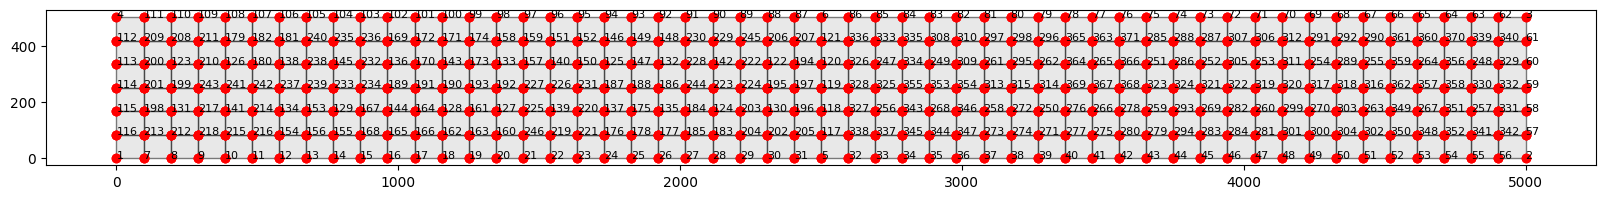

In [35]:
# Plot
plot_mesh(figsize=(20, 10) , 
          nodes=nodes,
            elements=elements, 
            show_node_labels=True, 
            show_element_labels=False)

In [36]:
# Setup system parameters
nodeList = nodes
elementList = elements

# Get total number of nodes and elements
nNodes = len(nodeList)
nElements = len(elementList)

# Define degrees of freedom per node (x, y displacements)
globalParameters = {'nDoF': 2}

# Calculate total system degrees of freedom
system_nDof = globalParameters['nDoF'] * nNodes

In [37]:
import gmsh
import numpy as np

gmsh.initialize()
gmsh.open(output_file)

F_line_global = np.zeros(system_nDof)  # Initialize the global load vector

for (dim, phys_id) in gmsh.model.getPhysicalGroups(1):  # "1" means dimension=1 (lines)
    if phys_id in load_dictionary:
        load_value = load_dictionary[phys_id]
        line_entities = gmsh.model.getEntitiesForPhysicalGroup(dim, phys_id)

        for line_tag in line_entities:
            elem_types, elem_tags_list, node_tags_list = gmsh.model.mesh.getElements(dim, line_tag)

            for elem_type, elem_tags, node_tags in zip(elem_types, elem_tags_list, node_tags_list):
                num_nodes = gmsh.model.mesh.getElementProperties(elem_type)[3]

                for i in range(len(elem_tags)):
                    if num_nodes == 2:
                        n1_tag = node_tags[2 * i]
                        n2_tag = node_tags[2 * i + 1]

                        node_start = node_map[n1_tag]
                        node_end   = node_map[n2_tag]

                        # Carga distribuida sobre línea lineal
                        line_load_vector = get_line_load_global_vector(
                            node_start=node_start,
                            node_end=node_end,
                            wj=load_value,
                            wk=load_value,
                            alpha_degree='x'
                        )

                        load_idx = np.hstack([node_start.idx, node_end.idx])
                        F_line_global[load_idx.astype(int)] += line_load_vector

                    elif num_nodes == 3:
                        n1_tag = node_tags[3 * i]
                        n2_tag = node_tags[3 * i + 1]
                        n3_tag = node_tags[3 * i + 2]

                        node_start = node_map[n1_tag]
                        node_mid   = node_map[n2_tag]
                        node_end   = node_map[n3_tag]

                        # Dividir la línea cuadrática en dos segmentos lineales
                        line_load_vector1 = get_line_load_global_vector(
                            node_start=node_start,
                            node_end=node_mid,
                            wj=load_value,
                            wk=load_value,
                            alpha_degree='x'
                        )

                        line_load_vector2 = get_line_load_global_vector(
                            node_start=node_mid,
                            node_end=node_end,
                            wj=load_value,
                            wk=load_value,
                            alpha_degree='x'
                        )

                        # Ensamblar segmento 1 (n1 → n2)
                        load_idx1 = np.hstack([node_start.idx, node_mid.idx])
                        F_line_global[load_idx1.astype(int)] += line_load_vector1

                        # Ensamblar segmento 2 (n2 → n3)
                        load_idx2 = np.hstack([node_mid.idx, node_end.idx])
                        F_line_global[load_idx2.astype(int)] += line_load_vector2

                    else:
                        raise NotImplementedError(f"Line element with {num_nodes} nodes is not supported.")


Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/calibrated_beam.msh'...
Info    : 15 entities
Info    : 371 nodes
Info    : 315 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/calibrated_beam.msh'


In [38]:
F_line_global[6*2-1]=Pload

In [39]:
import numpy as np
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

# Create global stiffness matrix (sparse format)
Kg = lil_matrix((system_nDof, system_nDof))

# Assemble global stiffness matrix (sparse format)
for element in elementList:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            Kg[i_global, j_global] += element.kg[i_local, j_local]

# Convert to CSR format for efficient solving
Kg = Kg.tocsr()

# Create nodal force vector
Fj = np.zeros(system_nDof)
for node in nodeList:
    Fj[node.idx] = node.nodalLoad

# Determine free and restrained degrees of freedom
nodeIndex = np.full(system_nDof, '', dtype=str)
for node in nodeList:
    nodeIndex[node.idx] = node.restrain

freeIndices = np.where(nodeIndex == 'f')[0]
restrainedIndices = np.where(nodeIndex == 'r')[0]

# Assemble total force vector
F = Fj + F_line_global

Ff = F[freeIndices]
Fr = F[restrainedIndices]

# Extract sparse submatrices
Kff = Kg[freeIndices[:, None], freeIndices]
Kfr = Kg[freeIndices[:, None], restrainedIndices]
Krf = Kg[restrainedIndices[:, None], freeIndices]
Krr = Kg[restrainedIndices[:, None], restrainedIndices]

# Solve the system: uf = Kff^-1 * (Ff - Kfr * ur)
uf = spsolve(Kff, Ff - Kfr @ Fr)
ur = np.zeros(len(restrainedIndices))

# Assemble complete displacement vector
u = np.zeros(system_nDof)
u[freeIndices] = uf
u[restrainedIndices] = ur

# Calculate reactions: Fr = Krf * uf + Krr * ur
Fr = Krf @ uf + Krr @ ur

F_reactions = np.zeros(system_nDof)
F_reactions[restrainedIndices] = Fr

# Total force vector (includes reactions)
F_total = Fj + F_reactions

In [40]:
# Total applied loads
LOAD_X = np.sum(F[::2])
LOAD_Y = np.sum(F[1::2])

# Total reactions
REACT_X = np.sum(F_reactions[::2])
REACT_Y = np.sum(F_reactions[1::2])

# Check equilibrium
print(f"Applied Load X: {LOAD_X:.4f},  Reaction X: {REACT_X:.4f},  Balance: {LOAD_X + REACT_X:.4e}")
print(f"Applied Load Y: {LOAD_Y:.4f},  Reaction Y: {REACT_Y:.4f},  Balance: {LOAD_Y + REACT_Y:.4e}")

Applied Load X: 0.0000,  Reaction X: -0.0000,  Balance: -7.9162e-09
Applied Load Y: -98066.5000,  Reaction Y: 98066.5000,  Balance: -1.6665e-07


In [41]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((nNodes, 3))
u_3d[:, 0] = u[0::2]  # Displacement in X
u_3d[:, 1] = u[1::2]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((nNodes, 3))
F_3d[:, 0] = F[0::2]  # Force in X
F_3d[:, 1] = F[1::2]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((nNodes, 3))
R_3d[:, 0] = F_total[0::2]  # Reaction in X
R_3d[:, 1] = F_total[1::2]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [42]:

# GMSH VISUALIZATION FUNCTIONS

def add_element_data_view(viewname, 
                          element_tags, 
                          data, 
                          visible=False):

    viewnum = gmsh.view.add(viewname)
    gmsh.view.addHomogeneousModelData(
        tag=viewnum,
        step=0,
        time=0,
        modelName=gmsh.model.getCurrent(),
        dataType="ElementData",
        numComponents=-1,
        tags=element_tags,
        data=data.reshape((-1))
    )
    gmsh.view.option.setNumber(viewnum, "Visible", 1 if visible else 0)
    return viewnum


def add_node_data_view(viewname, 
                       node_tags, 
                       data, 
                       visible=False, 
                       vector_type=None, 
                       displacement_factor=None):

    viewnum = gmsh.view.add(viewname)
    gmsh.view.addHomogeneousModelData(
        tag=viewnum,
        step=0,
        time=0,
        modelName=gmsh.model.getCurrent(),
        dataType="NodeData",
        numComponents=-1,
        tags=node_tags,
        data=data.reshape((-1))
    )
    gmsh.view.option.setNumber(viewnum, "Visible", 1 if visible else 0)
    gmsh.view.option.setNumber(viewnum, "GlyphLocation", 2)
    
    if vector_type is not None:
        gmsh.view.option.setNumber(viewnum, "VectorType", vector_type)
    
    if displacement_factor is not None:
        gmsh.view.option.setNumber(viewnum, "DisplacementFactor", displacement_factor)
    
    return viewnum

def compute_nodal_average(elements, 
                          element_data, 
                          nodes):

    node_map = {node.name: idx for idx, node in enumerate(nodes)}
    nNodes = len(nodes)
    
    nodal_values = np.zeros(nNodes)
    count = np.zeros(nNodes)
    
    # Accumulate values from elements
    for element, value in zip(elements, element_data):
        for node in element.nodes:
            idx = node_map[node.name]
            nodal_values[idx] += value
            count[idx] += 1
    
    # Compute average (avoid division by zero)
    count[count == 0] = 1
    nodal_values /= count
    
    return nodal_values

In [43]:
# VISUALIZE RESULTS IN GMSH


# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

2

In [44]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [45]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [46]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [47]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

-------------------------------------------------------
Version       : 4.15.0
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 20251026
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] LinuxJoystick MathEx[contrib] Med Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.11
PETSc version : 3.14.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------
